# Event IC-optimization — package workflow demo

Runs the full W&DL storyline pipeline for ONE event entirely through `heatwave_ic` function calls — no copy-pasted pipeline code. To run a different event (e.g. the PNW 2021 reproduction), change **only** the config path in the next cell.

Needs a GPU + GCS access → run on **Colab**, not the local CPU venv.

## Setup & environments

* Point notebook at event `CONFIG`

In [6]:
CONFIG = "configs/stjohns_aug2025.yaml"   # <-- the ONLY per-event change
REPO_URL = "https://github.com/ieadoboe/heatwave-initial-conditions.git"

import shutil, sys
from pathlib import Path

# Find a valid repo root: cwd, any parent, or an existing clone under cwd.
name = Path(REPO_URL).stem
candidates = [Path.cwd(), *Path.cwd().parents, Path.cwd() / name]
root = next((p for p in candidates if (p / "heatwave_ic").is_dir()), None)
if root is None and "google.colab" in sys.modules:
    shutil.rmtree(name, ignore_errors=True)   # clear stale/partial clones
    !git clone {REPO_URL}
    root = Path.cwd() / name
if root is None or not (root / "heatwave_ic").is_dir():
    raise RuntimeError(
        "heatwave_ic/ not found. Either the clone failed, or the package "
        "hasn't been pushed to GitHub yet (git push from the local repo)."
    )
%cd {root}
sys.path.insert(0, str(root))
if "google.colab" in sys.modules:
    %pip install -q -U neuralgcm dinosaur gcsfs optax tqdm pyyaml zarr

/content/heatwave-initial-conditions


## Load the event config

* Import pipeline functions from `heatwave_ic`
* Reads event YAML (config)
* Prints a summary of experiment

In [2]:
from heatwave_ic import (
    load_config, describe, load_model, build_ic_zarr, load_ic_on_model_grid,
    optimize_event, box_t1000_trajectory, make_run_dir,
    save_losses, save_state_fields, save_trajectory_nc, plots,
)

cfg = load_config(CONFIG)
print(describe(cfg))

stjohns_aug2025: target (47.562, -52.713°E), event 2025-08-09 → 2025-08-15 (peak 2025-08-12)
  init 2025-08-06 (lead 6 d), evolve 9 d, target window = last 5 d
  beta=10 lambda=100 T_ref=293.15 lr=5e-09 iters=75
  model v1_precip/stochastic_precip_2_8_deg.pkl  IC data/era5_ic_stjohns_aug2025_2025-08-06.zarr


## Model + initial conditions

* Downloads the NeuralGCM checkpoint from GCS
* Slices model's input and forcings variables at the init date out of ARCO-ERA5
* Saves as local IC zarr
* Regrids to 0.25 $\degree$

In [3]:
model = load_model(cfg["model_name"])
# build_ic_zarr(model, cfg)                       # no-op if already built

import numpy as np
from dinosaur import xarray_utils
from heatwave_ic import open_arco_era5

t0 = np.datetime64(cfg["run"]["init_date"])
full = open_arco_era5(cfg["paths"]["era5_arco"])
window = (full[model.input_variables + model.forcing_variables]
          .sel(time=slice(t0, t0 + np.timedelta64(2, "D")))
          .pipe(xarray_utils.selective_temporal_shift,
                variables=model.forcing_variables, time_shift="24 hours"))
window.compute().drop_encoding().to_zarr(cfg["paths"]["ic_zarr"], mode="w")

eval_era5 = load_ic_on_model_grid(model, cfg["paths"]["ic_zarr"])

/usr/local/lib/python3.12/dist-packages/zarr/api/asynchronous.py:231: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


# Optimize

`optimize_event` uses the config's (tuned) hyperparameters; keyword overrides sweep them without re-editing the YAML, e.g.
```python
optimize_event(model, eval_era5, cfg, beta=20, lam=30, iterations=30)
optimize_event(model, eval_era5, cfg, weights={"specific_humidity": 10})
```

## Run the optimization

* Encode the initial condition into model state
* Run Adam for N iterations, each iteration unrolling the full forecast and backpropagating the W&DL loss into the initial state
* Uses the tuned hyperparameters from the config
* Print the final loss, target box temperature and IC violation

In [4]:
result = optimize_event(model, eval_era5, cfg)
print(f"final loss {result['losses'][-1]:.4f}   "
      f"final box T {result['box_T_K'][-1] - 273.15:.2f} C   "
      f"IC violation {result['reg'][-1]:.4g}")

loss 173.1856  box T 294.43 K: 100%|██████████| 75/75 [20:25<00:00, 16.34s/it]   


final loss 173.1856   final box T 21.28 C   IC violation 0.02341


## Evaluate & plot the storyline

* Unrolls two forecasts - the original ERA5 initial condition & the optimized forecast
* Extracts the box-mean 1000hPa temperature trajectory for each
* Prints the storyline gain (how much hotter the optimiized peak is)
* Saves two figures: 1) loss curve & 2) unperturbed-vs-optimized storyline with the event window shaded

storyline gain: +1.08 C at the peak
Plot -> plots/stjohns_aug2025_opt_loss.pdf
Plot -> plots/stjohns_aug2025_storyline.pdf


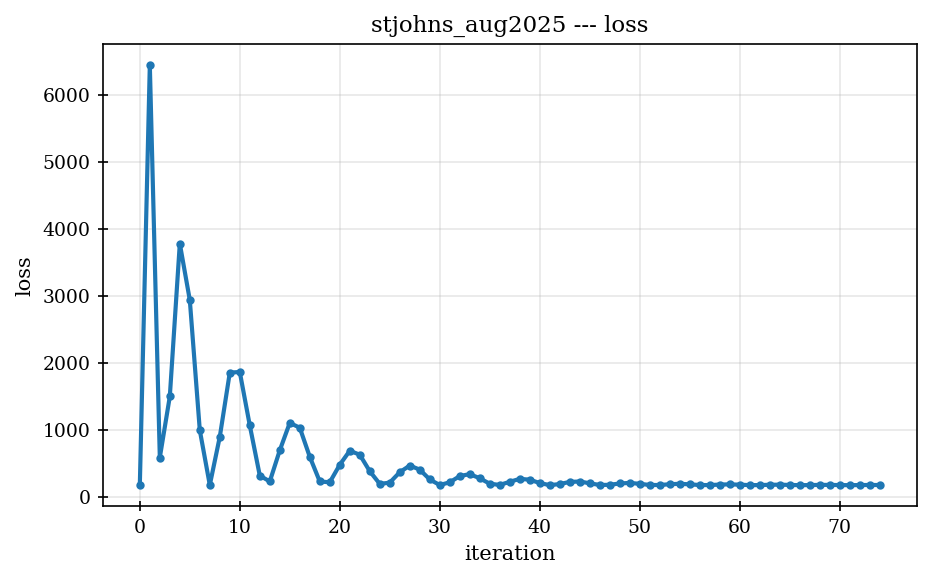

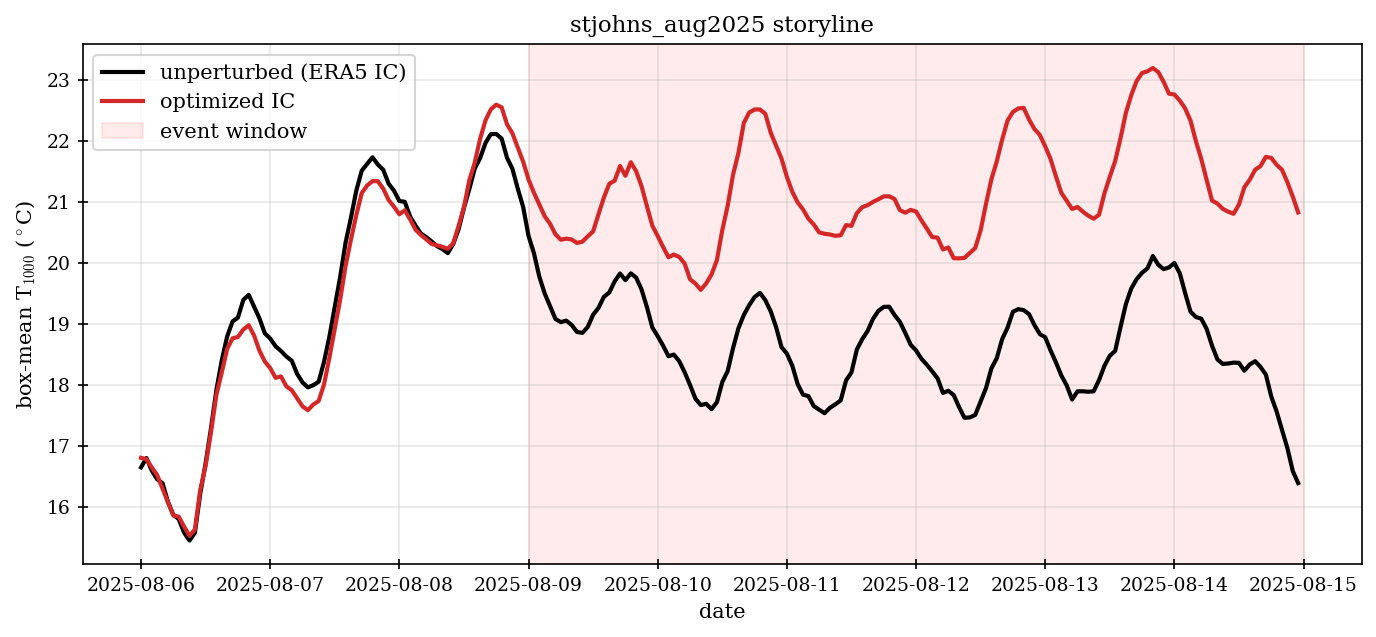

In [9]:
import matplotlib as mpl
mpl.rcParams.update({"text.usetex": False, "mathtext.fontset": "cm",
                     "font.serif": ["DejaVu Serif"]})

event, run = cfg["event"], cfg["run"]

traj_ori = box_t1000_trajectory(
    model, result["initial_state"], result["all_forcings"],
    result["outer_steps"], result["lat_i"], result["lon_i"], run["init_date"])
traj_opt = box_t1000_trajectory(
    model, result["optimized_state"], result["all_forcings"],
    result["outer_steps"], result["lat_i"], result["lon_i"], run["init_date"])

print(f"storyline gain: +{traj_opt.max() - traj_ori.max():.2f} C at the peak")

plots.plot_loss(result, title=f"{event['name']} --- loss",
                save=f"plots/{event['name']}_opt_loss.pdf")
plots.plot_storyline(traj_ori, traj_opt, event["start"], event["end"],
                     title=f"{event['name']} storyline",
                     save=f"plots/{event['name']}_storyline.pdf");

## Save outputs

Writes everything to a run directory under data/opt_runs/ whose name encodes the event and hyperparameters: the loss/temperature/regularization histories (.npy), the full optimized and original trajectories (.nc), and the optimized and original initial-state fields (surface pressure, vorticity, divergence) for the sensitivity-map analysis later.

In [12]:
from google.colab import drive
drive.mount('/content/drive')

cfg["paths"]["output_dir"] = "/content/drive/MyDrive/heatwave_runs"
out_dir = make_run_dir(cfg, result["params"])
save_losses(result, out_dir)
save_trajectory_nc(model, result["optimized_state"], result["all_forcings"],
                   result["outer_steps"], f"{out_dir}/optimized.nc")
save_trajectory_nc(model, result["initial_state"], result["all_forcings"],
                   result["outer_steps"], f"{out_dir}/original.nc")
save_state_fields(model, result["optimized_state"], out_dir, "opt")
save_state_fields(model, result["initial_state"], out_dir, "original")
print(f"outputs -> {out_dir}")

Mounted at /content/drive
outputs -> /content/drive/MyDrive/heatwave_runs/stjohns_aug2025_lr5em09_it75_lam100_b10_d9


CLI equivalent of this whole notebook:
```bash
python scripts/optimize_event.py --config configs/stjohns_aug2025.yaml --build-ic
python scripts/optimize_event.py --config configs/stjohns_aug2025.yaml
```